# Research GAP AI 멀티 에이전트

**주요 내용**

- **에이전트 생성**: 에이전트를 정의하고, 이를 LangGraph 그래프의 노드로 설정하는 방법  
- **도구 정의**: 에이전트가 사용할 도구를 정의하고 노드로 추가하는 방법  
- **그래프 생성**: 에이전트와 도구를 연결하여 멀티 에이전트 네트워크 그래프를 구성하는 방법  
- **상태 정의**: 그래프 상태를 정의하고, 각 에이전트의 동작에 필요한 상태 정보를 관리하는 방법  
- **에이전트 노드 정의**: 각각의 전문 에이전트를 노드로 정의하는 방법  
- **도구 노드 정의**: 도구를 노드로 정의하고 에이전트가 이 도구를 활용하도록 하는 방법  
- **엣지 로직 정의**: 에이전트 결과에 따라 다른 에이전트나 도구로 분기하는 로직을 설정하는 방법  
- **그래프 정의**: 위에서 정의한 에이전트, 도구, 상태, 엣지 로직을 종합하여 최종 그래프를 구성하는 방법  
- **그래프 실행**: 구성된 그래프를 호출하고 실제 작업을 수행하는 방법

In [1]:
from dotenv import load_dotenv
from utils import logging

load_dotenv()
logging.langsmith("Gapago_V1")

LangSmith 추적을 시작합니다.
[프로젝트명]
Gapago_V1


### 1. 상태 정의

In [ ]:
"""
GAPAGO State Definitions
This module defines the states used at each stage of the research process.
"""

from typing import List, Annotated, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph import add_messages
from typing import Sequence
from typing_extensions import Annotated


# ====================== Data Models ======================
class Paper(BaseModel):
    """Individual paper metadata from arXiv."""

    paper_id: str
    title: str
    abstract: str
    url: str
    year: int
    authors: List[str] = Field(default_factory=list)
    score_bm25: float = 0.0


class LimitationItem(BaseModel):
    """Extracted limitation from a paper."""

    paper_id: str
    claim: str
    evidence_quote: str


class GapCandidate(BaseModel):
    """Research gap identified from limitations."""

    axis: str  # 축 key
    axis_label: str = ""  # 축 한글/영문 레이블
    axis_type: str = "fixed"  # "fixed" | "dynamic"
    gap_statement: str  # 핵심 GAP 1문장 요약
    elaboration: str = ""  # GAP 상세 설명 (2~3문장)
    proposed_topic: str = ""  # 제안 연구 주제
    repeat_count: int = 0  # 반복 등장 논문 수
    supporting_papers: List[str] = Field(default_factory=list)
    supporting_quotes: List[str] = Field(default_factory=list)


class CriticScores(BaseModel):
    """Quality scores for the analysis."""

    query_specificity: float = Field(0.0, ge=0.0, le=1.0)
    paper_relevance: float = Field(0.0, ge=0.0, le=1.0)
    groundedness: float = Field(0.0, ge=0.0, le=1.0)


class DimensionScore(BaseModel):
    """개별 평가 차원 점수"""

    dimension: str
    label: str
    score: int = Field(0, ge=0, le=10)
    reasoning: str = ""


class EvaluationResult(BaseModel):
    """LLM-as-a-Judge 최종 평가 결과"""

    dimension_scores: list[DimensionScore] = Field(default_factory=list)
    average_score: float = Field(0.0, ge=0.0, le=10.0)
    summary: str = ""


# ====================== State Definitions ======================
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]  # Agent 간 공유하는 메시지 목록
    sender: Annotated[str, "The sender of the last message"]  # 메시지의 발신자. 즉, 무슨 Agent로부터 온 메시지인지 명시

    user_question: str
    refined_query: str
    keywords: List[str]
    negative_keywords: List[str]

    missing_slots: List[str]
    clarify_questions: List[str]
    query_proposal: str
    query_approved: bool
    ask_human: bool

    papers: List[dict]
    limitations: List[dict]
    gaps: List[dict]
    critic: Optional[dict]

    iteration: int
    max_iterations: int
    errors: List[str]
    trace: dict

### 2. 도구 정의

In [ ]:
"""
GAPAGO State Definitions
This module defines various tools used in the research process.
"""

from langchain_core.tools import tool
from langchain_community.retrievers import ArxivRetriever
from utils.tavily import TavilySearch
from langchain_core.runnables import RunnableConfig

# 1. 웹 검색 도구
tavily_tool = TavilySearch(max_results=5)

# 2. 논문 검색 도구
arxiv_retriever = ArxivRetriever(
    load_max_docs=3,
    load_all_available_meta=True,
    get_full_documents=True,
)

class ArxivSearchInput(BaseModel):
    query: str = Field(description="arXiv 검색 쿼리")
    max_docs: int = Field(default=3, description="가져올 문서 수")

def _format_arxiv_docs(arxiv_search_results) -> str:
    return "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata.get("entry_id","")}" '
            f'date="{doc.metadata.get("Published", "")}" '
            f'authors="{doc.metadata.get("Authors", "")}"/>\n'
            f'<Title>\n{doc.metadata.get("Title","")}\n</Title>\n\n'
            f'<Summary>\n{doc.metadata.get("Summary","")}\n</Summary>\n\n'
            f"<Content>\n{doc.page_content}\n</Content>\n"
            f"</Document>"
            for doc in arxiv_search_results
        ]
    )


@tool(args_schema=ArxivSearchInput)
def arxiv_search_tool(query: str, max_docs: int = 1) -> str:
    """Search arXiv and return formatted documents for LLM context."""
    try:
        results = arxiv_retriever.invoke(
            query,
            load_max_docs=max_docs,
            load_all_available_meta=True,
            get_full_documents=True,
        )
        return _format_arxiv_docs(results)
    except Exception as e:
        return f"<Error>Arxiv search failed: {str(e)}</Error>"


# 3. 그 외 도구 추가 필요


# ==================================================================

# 4. 에이전트별 도구 모음
QUERY_TOOLS = []
RETRIEVAL_TOOLS = [arxiv_search_tool, tavily_tool]
LIMITATION_TOOLS = []  # 보통 tool 없이 LLM로 추출
GAP_INFER_TOOLS = []  # 보통 tool 없이 LLM로 추론
CRITIC_TOOLS = []  # 점수 계산을 tool로 한다면, python_repl_tool 추가 가능

### 3. Agent(노드) 생성

- Agent 별 Prompt 버전 관리 위해 따로 폴더로 관리 필요

In [4]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    openai_api_version="2024-12-01-preview",
    azure_deployment="gpt-5.1-chat",
)


## Version 1.
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a specialized AI agent participating in a multi-agent Research GAP analysis system. "
        "Each agent has a distinct role in the pipeline and must strictly follow its assigned responsibility.\n\n"
        "SYSTEM CONTEXT:\n"
        "- The overall objective is to identify structured Research Gaps from multiple academic sources.\n"
        "- The pipeline includes Query Analysis, Research Intelligence, GAP Inference, and Critic evaluation.\n"
        "- Outputs must be structured, evidence-based, and aligned with the user’s research question.\n\n"
        "BEHAVIOR RULES:\n"
        "1. Perform ONLY the task assigned to your current role.\n"
        "2. Use tools when necessary and avoid hallucinating information.\n"
        "3. Base claims strictly on retrieved evidence.\n"
        "4. If ambiguity is detected, explicitly state it and request clarification.\n"
        "5. Provide structured outputs (e.g., JSON-style sections, bullet lists, labeled criteria).\n"
        "6. Do NOT generate a final research topic unless you are the GAP Inference Agent.\n"
        "7. Do NOT evaluate quality unless you are the Critic Agent.\n"
        "8. If your stage is complete and ready for the next step, clearly indicate completion.\n\n"
        "COLLABORATION PROTOCOL:\n"
        "- You may receive intermediate structured state from previous agents.\n"
        "- Preserve state consistency and do not overwrite verified evidence.\n"
        "- If you determine that the final deliverable has been achieved, prefix the response with 'FINAL ANSWER'.\n\n"
        f"{suffix}"
    )


## Version 2.
# def make_system_prompt(suffix: str) -> str:
#     return (
#         "You are an AI assistant in a multi-step research-gap analysis workflow. "
#         "Follow your assigned role and produce structured, evidence-based outputs. "
#         "If information is missing or ambiguous, ask for clarification. "
#         "Do not invent citations or claims.\n\n"
#         f"{suffix}"
#     )

c:\Users\Kisti\miniconda3\envs\agent\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 3-1) Query Analysis Agent
query_analysis_agent = create_agent(
    llm,
    tools=QUERY_TOOLS,
    system_prompt=make_system_prompt(
        "ROLE: Query Analysis Agent\n"
        "Task:\n"
        "1) Detect ambiguity: domain/data/method/time/metrics etc.\n"
        "2) Propose a refined search query.\n"
        "3) If ambiguous, ask for missing slots and request user approval.\n\n"
        "You MUST output:\n"
        "- ROUTE: RETRIEVE  OR  ROUTE: NEED_USER_CLARIFICATION\n"
        "- query_proposal: <string>\n"
        "- missing_slots: [..]\n"
        "- clarify_questions: [..]\n"
        "- keywords: [..]\n"
        "- negative_keywords: [..]\n\n"
        "Keep it concise and machine-parseable (JSON-like is OK).\n"
    ),
)


def query_analysis_node(state: AgentState) -> AgentState:
    it = state.get("iteration", 0) + 1

    result = query_analysis_agent.invoke(state)
    content = result["messages"][-1].content if result.get("messages") else ""

    need_clarify = "ROUTE: NEED_USER_CLARIFICATION" in (content or "")
    max_it = state.get("max_iterations", 3)
    if it >= max_it:
        need_clarify = False

    # ask_human: interrupt
    ask_human = bool(need_clarify) and not state.get("query_approved", False)

    last = AIMessage(content=content, name="query_analysis")

    return {
        "messages": [last],
        "sender": "query_analysis",
        "ask_human": ask_human,
        "iteration": it,
    }


def human_clarify_node(state: AgentState) -> AgentState:
    """
    Interrupt 전용 노드
    여기서는 LLM 호출/자동 응답 생성하지 않음
    UI/CLI에서 snapshot을 보고 사용자 입력을 받은 뒤 app.update_state로 아래 필드를 채움:
      - query_approved: bool
      - (optional) refined_query or user feedback message
    """
    # 아무것도 변경하지 않아도 됨 (interrupt로 멈출 것)
    return {"sender": "human_clarify"}


# ========================================================================================


# 3-2) Paper Retrieval Agent (Research Intelligence / Paper S-M + Web Search)
paper_retrieval_agent = create_agent(
    llm,
    tools=RETRIEVAL_TOOLS,
    system_prompt=make_system_prompt(
        "ROLE: Paper Retrieval Agent\n"
        "You retrieve relevant papers/web sources using provided tools.\n"
        "Return a structured list of candidates with title, year, venue/source, abstract/snippet, and relevance score.\n"
        "Do NOT infer gaps. Do NOT summarize beyond what is needed for matching.\n"
    ),
)


def paper_retrieval_node(state: AgentState) -> AgentState:
    result = paper_retrieval_agent.invoke(state)
    last = AIMessage(content=result["messages"][-1].content, name="paper_retrieval")
    return {"messages": [last], "sender": "paper_retrieval"}


# ========================================================================================

# 3-3) Limitation Extract Agent
limitation_extract_agent = create_agent(
    llm,
    tools=LIMITATION_TOOLS,
    system_prompt=make_system_prompt(
        "ROLE: Limitation Extract Agent\n"
        "You extract limitation/future-work statements from retrieved papers/snippets.\n"
        "Output be structured: paper_id -> [limitation_sentences], plus brief rationale.\n"
        "Do NOT infer gaps yet.\n"
    ),
)


def limitation_extract_node(state: AgentState) -> AgentState:
    result = limitation_extract_agent.invoke(state)
    last = AIMessage(content=result["messages"][-1].content, name="limitation_extract")
    return {"messages": [last], "sender": "limitation_extract"}


# ========================================================================================

# 3-4) GAP Inference Agent
gap_infer_agent = create_agent(
    llm,
    tools=GAP_INFER_TOOLS,
    system_prompt=make_system_prompt(
        "ROLE: GAP Inference Agent\n"
        "You cluster limitations into K criteria axes (e.g., data/robustness/scalability/evaluation/usability).\n"
        "Infer recurring core research gaps and propose candidate research topics.\n"
        "Each gap/topic MUST include supporting evidence references (paper_id + sentence).\n"
    ),
)


def gap_infer_node(state: AgentState) -> AgentState:
    result = gap_infer_agent.invoke(state)
    last = AIMessage(content=result["messages"][-1].content, name="gap_infer")
    return {"messages": [last], "sender": "gap_infer"}


# ========================================================================================

# 3-5) Critic Score Agent
critic_score_agent = create_agent(
    llm,
    tools=CRITIC_TOOLS,
    system_prompt=make_system_prompt(
        "ROLE: Critic Agent\n"
        "You mevaluate the pipeline outputs (query specificity, paper alignment, evidence support).\n"
        "Return scores + flags + a routing decision tag among:\n"
        "- DECISION: ACCEPT\n"
        "- DECISION: REDO_RETRIEVAL\n"
        "- DECISION: REFINE_QUERY\n"
        "Do NOT generate new gaps/topics.\n"
    ),
)


def critic_score_node(state: AgentState) -> AgentState:
    result = critic_score_agent.invoke(state)
    last = AIMessage(content=result["messages"][-1].content, name="critic_score")
    return {"messages": [last], "sender": "critic_score"}


# ========================================================================================

# 3-6) response Agent
final_response_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=make_system_prompt(
        "Write a final report for the user based on prior messages.\n"
        "Include:\n"
        "1) Related papers: title/year + one-line relevance.\n"
        "2) Key limitations: grouped.\n"
        "3) Research gaps: clustered with evidence references.\n"
        "4) Critic scores : four scores and decision/flags in a compact block.\n"
        "Finish with: FINAL ANSWER\n"
    ),
)


def final_response_node(state: AgentState) -> AgentState:
    result = final_response_agent.invoke(state)
    last = AIMessage(content=result["messages"][-1].content, name="final_response")
    return {"messages": [last], "sender": "final_response"}

### 4. Routing

In [ ]:
def route_after_query(state: AgentState) -> str:
    """
    query_analysis -> (paper_retrieval) 기본
    모호하면 query_analysis에서 재질문/보완 후 다시 query_analysis로 루프
    """
    last = state["messages"][-1].content if state.get("messages") else ""

    if "FINAL ANSWER" in (last or ""):
        return END

    if state.get("ask_human", False) and not state.get("query_approved", False):
        return "human_clarify"

    return "paper_retrieval"


def route_after_critic(state: AgentState) -> str:
    """
    critic_score ->
      - ACCEPT          -> final_response (최종 리포트 작성)
      - REDO_RETRIEVAL  -> paper_retrieval
      - REFINE_QUERY    -> query_analysis
      - FINAL ANSWER    -> END (안전장치)
    """
    last = state["messages"][-1].content or ""

    # 어떤 노드든 FINAL ANSWER가 나오면 즉시 종료 (안전장치)
    if "FINAL ANSWER" in last:
        return END

    if "DECISION: ACCEPT" in last:
        return "final_response"

    if "DECISION: REDO_RETRIEVAL" in last:
        return "paper_retrieval"

    if "DECISION: REFINE_QUERY" in last:
        return "query_analysis"

    # 태그가 없다면 보수적으로 query 재정제 쪽으로
    return "query_analysis"

### 5. Graph 구성

In [7]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("query_analysis", query_analysis_node)
workflow.add_node("human_clarify", human_clarify_node)
workflow.add_node("paper_retrieval", paper_retrieval_node)
workflow.add_node("limitation_extract", limitation_extract_node)
workflow.add_node("gap_infer", gap_infer_node)
workflow.add_node("critic_score", critic_score_node)
workflow.add_node("final_response", final_response_node)

# start -> query_analysis
workflow.add_edge(START, "query_analysis")

# query_analysis -> (paper_retrieval) 또는 (human_clarify)
workflow.add_conditional_edges(
    "query_analysis",
    route_after_query,
    {
        "human_clarify": "human_clarify",
        "paper_retrieval": "paper_retrieval",
        END: END,
    },
)

# paper_retrieval -> limitation_extract -> gap_infer -> critic_score (실선)
workflow.add_edge("human_clarify", "query_analysis")
workflow.add_edge("paper_retrieval", "limitation_extract")
workflow.add_edge("limitation_extract", "gap_infer")
workflow.add_edge("gap_infer", "critic_score")

# critic_score -> (accept/end) 또는 (redo_retrieval/paper_retrieval) 또는 (refine_query/query_analysis)
workflow.add_conditional_edges(
    "critic_score",
    route_after_critic,
    {
        "paper_retrieval": "paper_retrieval",
        "query_analysis": "query_analysis",
        "final_response": "final_response",
        END: END,
    },
)

workflow.add_edge("final_response", END)

app = workflow.compile(
    checkpointer=MemorySaver(),
    interrupt_before=["human_clarify"],
)

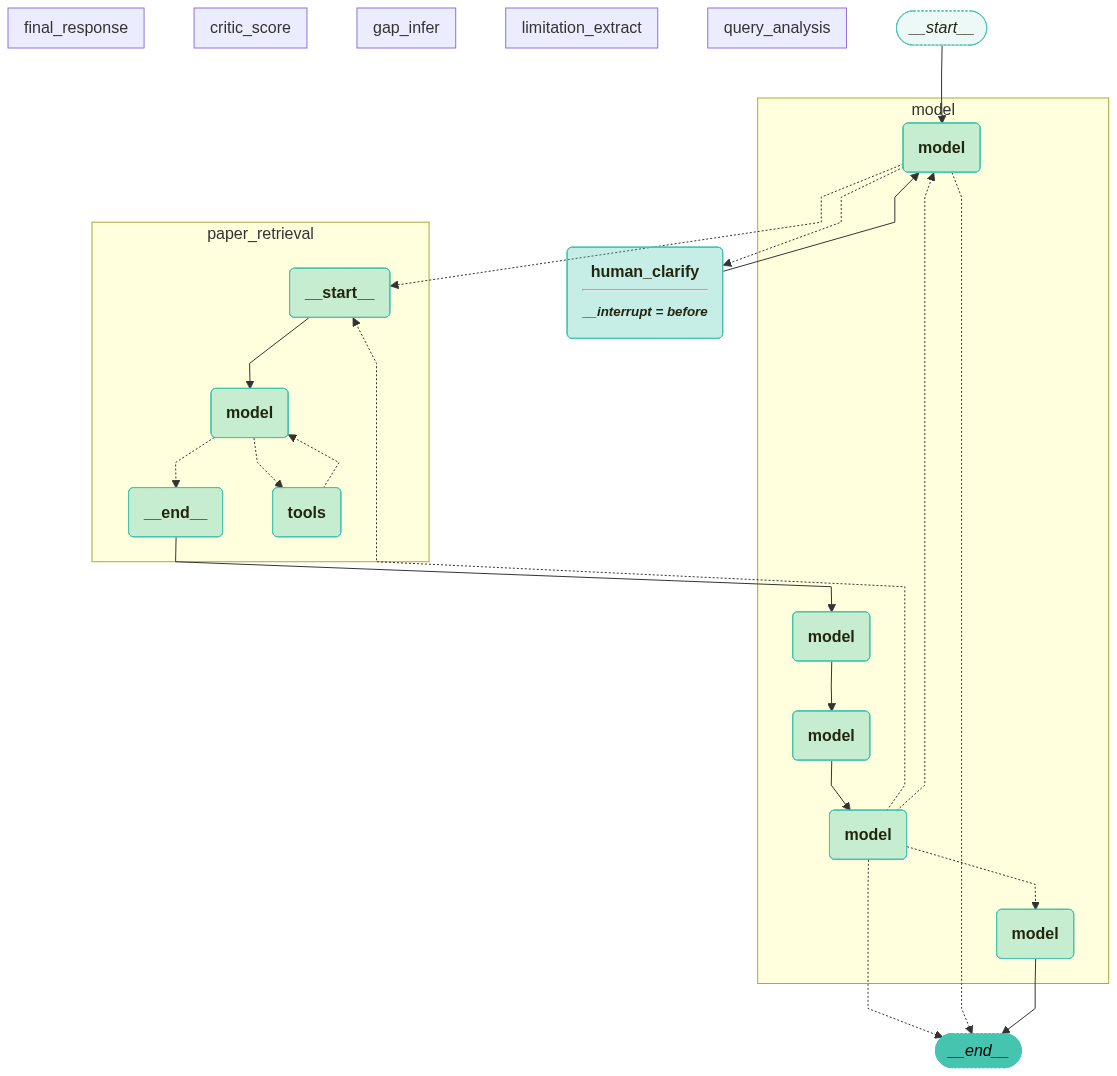

In [ ]:
from utils.vis_graph import visualize_graph

visualize_graph(app, xray=True)

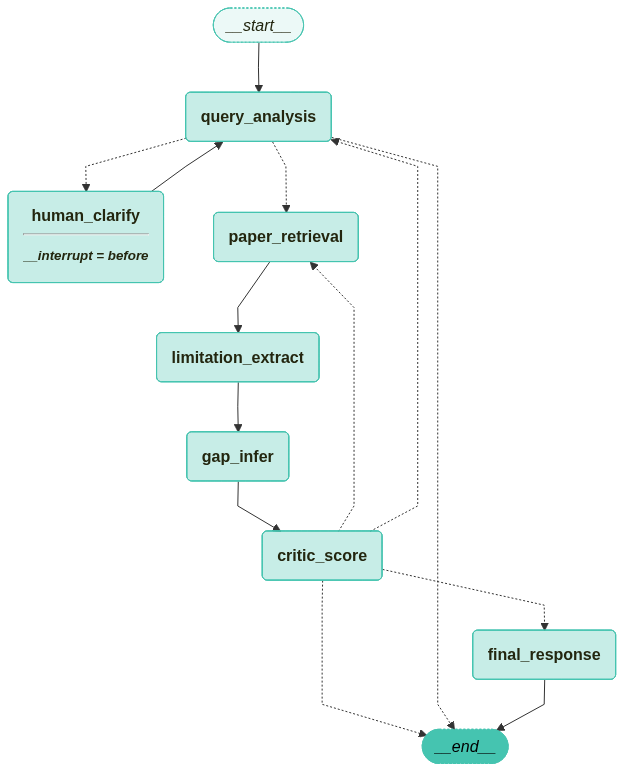

In [9]:
visualize_graph(app, xray=False)

### 6. Agent 실행

In [10]:
inputs = {"messages": [HumanMessage(content="Domain adaptation in clinical drug")]}
config = {"configurable": {"thread_id": "1"}}
output = app.invoke(inputs, config)

print(output["messages"][-1].content)

ROUTE: NEED_USER_CLARIFICATION

query_proposal: "domain adaptation methods applied to clinical drug research, including clinical trial data, pharmacology datasets, and real‑world evidence"

missing_slots:
- specific task (e.g., prediction, representation learning, safety signal detection, treatment effect estimation)
- data modality (EHR, clinical notes, omics, imaging, trial datasets)
- domain shift type (cross‑institution, cross‑population, preclinical→clinical, synthetic→real)
- timeframe (recent years?)
- evaluation metrics of interest

clarify_questions:
- What specific task within clinical drug research should domain adaptation address?
- Which data types or modalities are involved?
- What kind of domain shift are you interested in studying?
- Should the search focus on methodological papers, applied studies, or both?
- Do you want a specific timeframe (e.g., last 5 years)?

keywords:
- domain adaptation
- transfer learning
- clinical drug development
- clinical trials
- pharmaco

In [11]:
# 그래프 상태 스냅샷 생성
snapshot = app.get_state(config)

# 다음 스냅샷 상태 접근
snapshot.next

('human_clarify',)

In [ ]:
app.update_state(
    config,
    {
        "query_approved": True,
        "ask_human": False,
        "messages": [HumanMessage(content="APPROVE")],
    },
)

for event in app.stream(None, config, stream_mode="values"):
    if "messages" in event:
        print("==>", event["messages"][-1].content)

==> APPROVE
==> ROLE: Paper Retrieval Agent  
STATUS: COMPLETE  
Below is the structured list of retrieved candidate papers relevant to **domain adaptation in clinical drug research**, including clinical trials, drug response prediction, and pharmacology-related domain shift problems.

CANDIDATE PAPERS:

1.  
title: Enhancing Longitudinal Clinical Trial Efficiency with Digital Twins and Prognostic Covariate-Adjusted MMRM  
year: 2024  
venue: arXiv (stat.AP)  
snippet: Introduces AI‑generated prognostic covariates for clinical trials using digital twins; improves treatment effect precision and reduces sample size.  
relevance_score: 0.62 (Not domain‑adaptation focused but touches AI modeling in clinical trial settings)

2.  
title: Knowledge‑Guided Domain Adaptation Model for Transferring Drug Response Prediction from Cell Lines to Patients (TransDRP)  
year: 2025 (AAAI-25)  
venue: AAAI  
snippet: Proposes unsupervised domain adaptation aligning preclinical cell‑line data with patient

In [13]:
output2 = app.invoke(None, config)  # resume
print(output2["messages"][-1].content)

Below is your consolidated final report synthesizing the multi‑agent pipeline.  
All content is based strictly on retrieved evidence, extracted limitations, and validated gap inference.

--------------------------------------------------
RELATED PAPERS (TITLE / YEAR / ONE‑LINE RELEVANCE)
--------------------------------------------------
1. Enhancing Longitudinal Clinical Trial Efficiency with Digital Twins and Prognostic Covariate‑Adjusted MMRM (2024)  
   – AI‑driven clinical trial modeling; not domain‑adaptation focused but relevant to clinical modeling context.

2. TransDRP: Knowledge‑Guided Domain Adaptation for Drug Response Prediction (2025)  
   – Directly tackles preclinical→patient domain adaptation for drug response prediction.

3. PACE: Patient‑Informed Domain Adaptation Improves Clinical Drug Sensitivity Prediction (2021)  
   – Uses patient‑informed adaptation to improve prediction of sensitivity vs. resistance.

4. PRECISE: A Domain Adaptation Approach to Transfer Predic